# Task 1: Data Loading & Exploratory Data Analysis (EDA)


## 1.1 Load the dataset

In [94]:
import pandas as pd
import numpy as np

In [95]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [96]:
print("DataFrame Information:", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
DataFrame Information: None


In [97]:
print("Statistical Summary:", df.describe())

Statistical Summary:        CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [98]:
print("Shape of the DataFrame:", df.shape)

Shape of the DataFrame: (200, 5)


In [99]:
print("Missing Values:", df.isnull().sum())

Missing Values: CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## 1.2 Rename and drop columns

In [100]:
df.rename(columns={
    "Annual Income (k$)":"Annual_Income",
    "Spending Score (1-100)":"Spending_Score"
}, inplace=True)

df.drop(columns=["CustomerID"], inplace=True)

df.head()

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## 1.3 Encode Gender

In [101]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

df.head()

,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


## 1.4 Univariate distributions

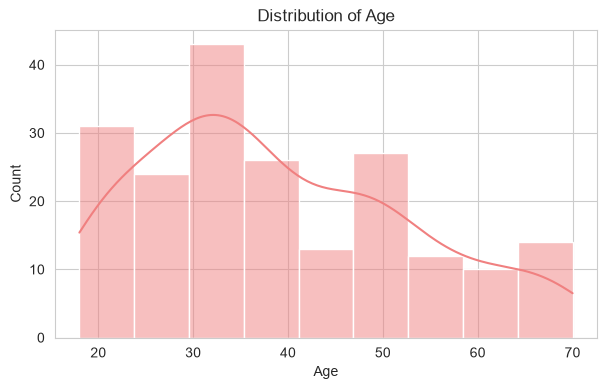

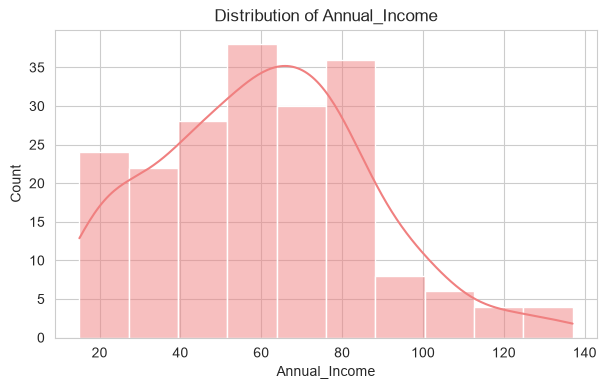

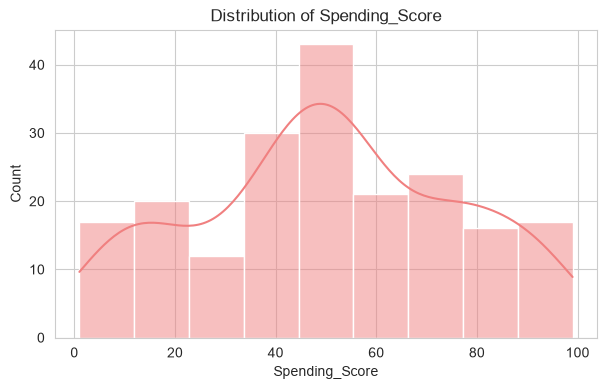

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

columns = ["Age","Annual_Income","Spending_Score"]

for col in columns:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True,color="lightcoral")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 1.5 Pairplot & correlation heatmap

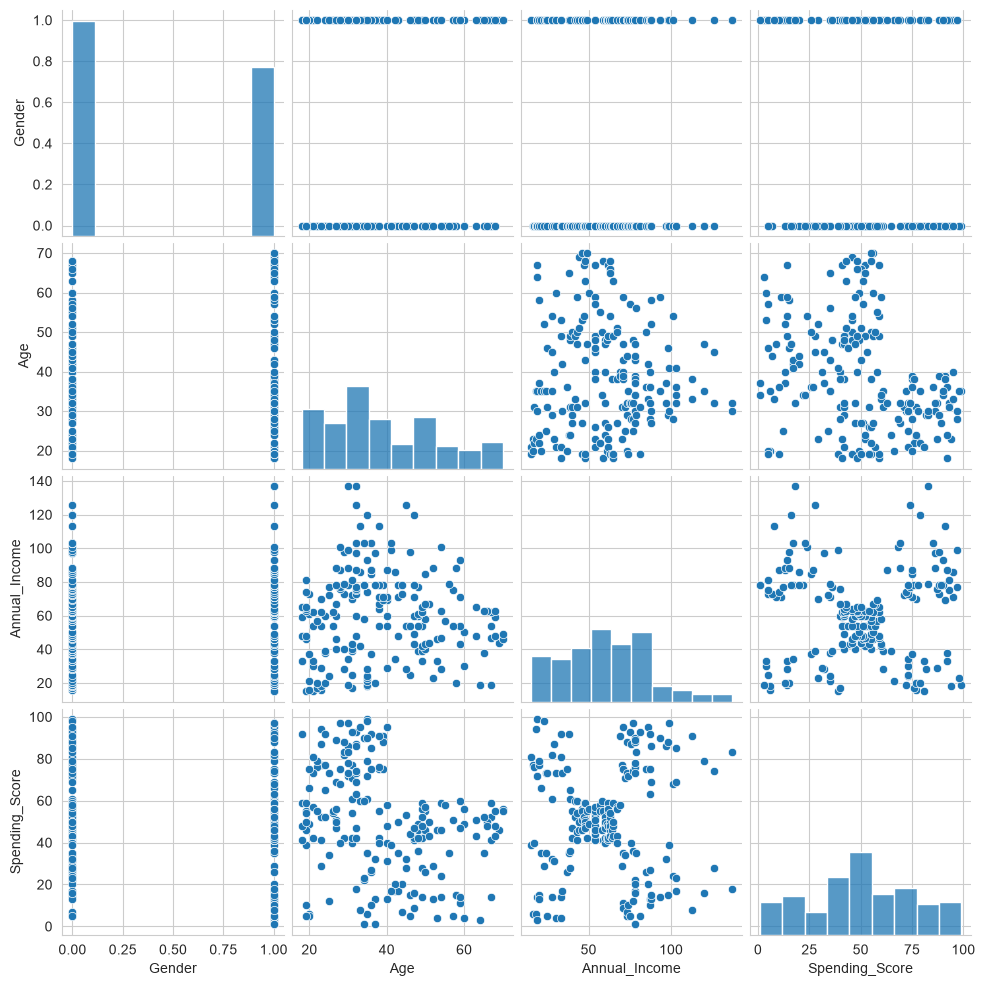

In [103]:
sns.pairplot(df)
plt.show()

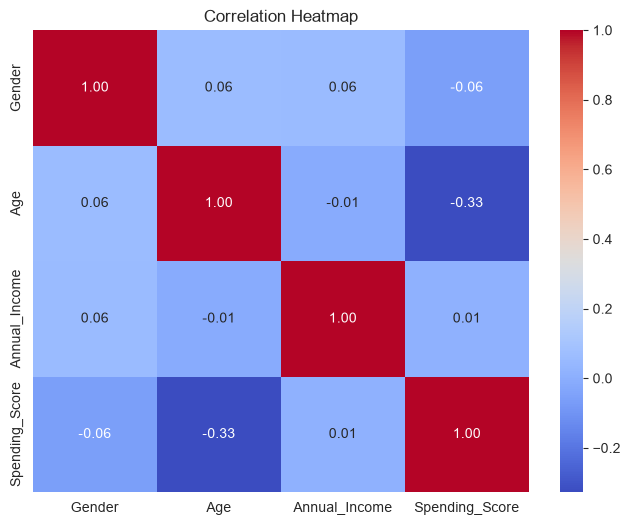

In [104]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## 1.6 Summary Markdown cell

#### **EDA Summary**

- The dataset contains 200 customer records with no missing values or duplicate records, making it suitable for clustering.
- The pairplot suggests that customers naturally form groups when comparing Annual Income and Spending Score.
- Age has only a weak relationship with Annual Income and Spending Score, while Annual Income and Spending Score show better separation for customer segmentation.
- The correlation heatmap indicates no strong linear correlation among variables, which is common in customer segmentation datasets.
- Annual Income and Spending Score are selected as the primary features for clustering because they provide the clearest visual separation between customer groups and produce meaningful business segments.

# Task 2: Feature Scaling & Feature Selection

## 2.1 Scale features



In [105]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[['Age', 'Annual_Income', 'Spending_Score']] = scaler.fit_transform(
    df[['Age', 'Annual_Income', 'Spending_Score']]
)

df_scaled.head()

,Gender,Age,Annual_Income,Spending_Score
0,1,-1.424569,-1.738999,-0.434801
1,1,-1.281035,-1.738999,1.195704
2,0,-1.352802,-1.700830,-1.715913
3,0,-1.137502,-1.700830,1.040418
4,0,-0.563369,-1.662660,-0.395980


StandardScaler transforms numerical features so they have a mean of 0 and a standard deviation of 1. This ensures that all features contribute equally during distance calculations in clustering algorithms.

## 2.2 Select 2-feature subset


In [106]:
df_2f = df_scaled[['Annual_Income', 'Spending_Score']]

df_2f.head()

,Annual_Income,Spending_Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [107]:
print("Shape of df_2f:", df_2f.shape)

Shape of df_2f: (200, 2)


Annual_Income and Spending_Score are selected because they provide the clearest customer separation and make cluster visualization simple in a 2D scatter plot.

#### **Why are only two features selected?**

The dataset contains four features (Gender, Age, Annual_Income, and Spending_Score). Although all four features can be used for clustering, this project mainly uses **Annual_Income** and **Spending_Score** because:

- They show the clearest customer grouping.
- They allow easy 2D scatter plot visualization without using PCA.
- They make cluster interpretation simple and understandable.

Using all four features is also valid and will be explored in **Task 6 (Extension)**, but the primary clustering tasks use **df_2f** for better visual clarity.

## 2.3 Explain scaling

#### **Why is StandardScaler Used?**

K-Means, Hierarchical Clustering, and DBSCAN are distance-based algorithms. Features with larger values can dominate the distance calculation.

For example:
- Annual Income ranges from about **15–137**
- Spending Score ranges from **1–100**

Without scaling, Annual Income would have a greater influence on clustering. StandardScaler makes all numerical features comparable, resulting in more accurate and balanced clusters.

# Task 3: K-Means Clustering 

## 3.1 Elbow Method



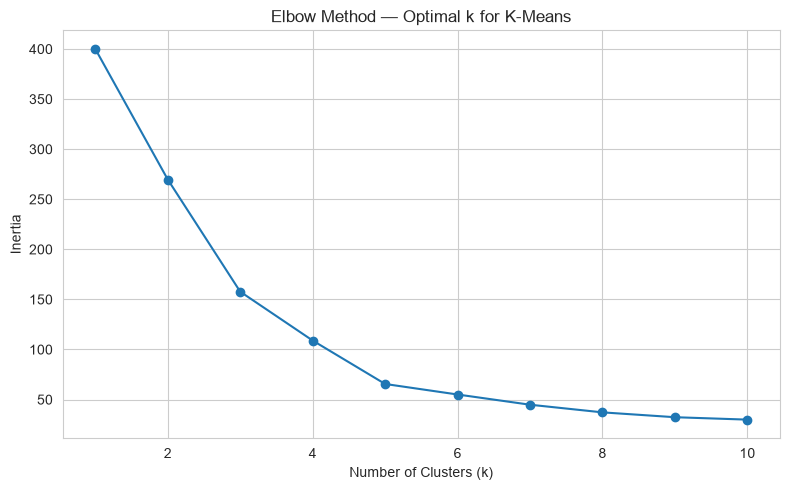

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df_2f)
    inertia.append(model.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia") # wcss(within cluster sum of squares)
plt.title("Elbow Method — Optimal k for K-Means")
plt.grid(True)
plt.tight_layout()
plt.show()

#### **What is Inertia?**

Inertia is the sum of squared distances between each data point and its nearest cluster centroid.

As the number of clusters increases, inertia decreases. The **elbow point** is where the decrease becomes less significant, indicating a good balance between cluster quality and model complexity.

## 3.2 Silhouette Score

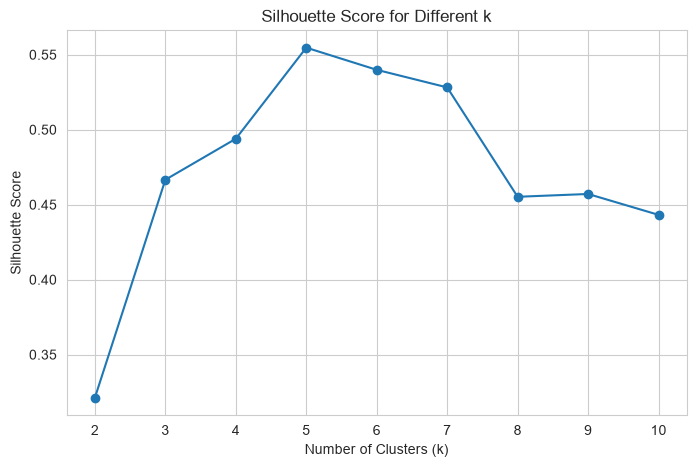

Best k based on Silhouette Score: 5


In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(df_2f)
    score = silhouette_score(df_2f, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score") 
plt.title("Silhouette Score for Different k")
plt.grid(True)
plt.show()

best_k = range(2,11)[silhouette_scores.index(max(silhouette_scores))]
print("Best k based on Silhouette Score:", best_k)

#### **What is the Silhouette Score?**

The Silhouette Score measures how well data points fit within their own cluster compared to other clusters.

- Score close to **1** → Well-separated clusters
- Score close to **0** → Overlapping clusters
- Score less than **0** → Poor clustering

The value of **k** with the highest Silhouette Score is considered the best choice.

## 3.3 Fit final K-Means model

In [110]:
from sklearn.cluster import KMeans

# Final K-Means Model
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Predict clusters
df["KMeans_Cluster"] = kmeans.fit_predict(df_2f)

# Display first rows
df.head()

,Gender,Age,Annual_Income,Spending_Score,KMeans_Cluster
0,1,19,15,39,4
1,1,21,15,81,2
2,0,20,16,6,4
3,0,23,16,77,2
4,0,31,17,40,4


The K-Means model assigns each customer to one of five clusters based on Annual Income and Spending Score. These labels will be used for visualization and business analysis.

## 3.4 Visualise K-Means clusters

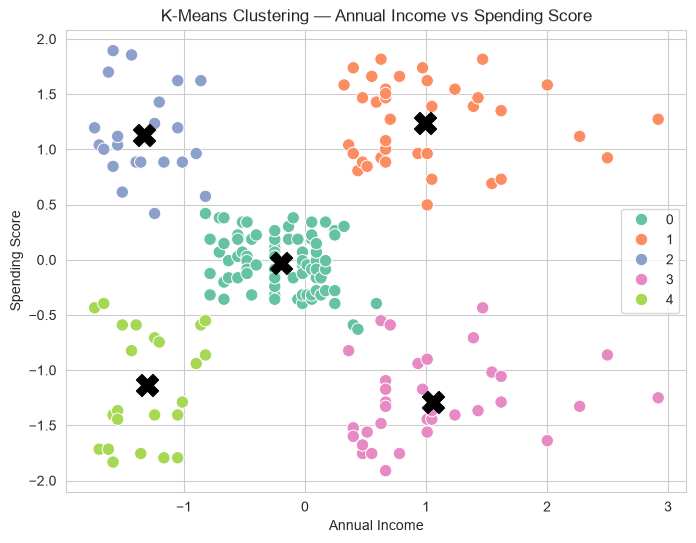

In [111]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_2f["Annual_Income"],
    y=df_2f["Spending_Score"],
    hue=df["KMeans_Cluster"],
    palette="Set2",
    s=80,
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c="black",
    marker="X",
    s=250
)

plt.title("K-Means Clustering — Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

The scatter plot shows five customer groups based on income and spending behavior. The black **X** markers represent the cluster centroids, which are the center of each cluster.

## 3.5 Cluster profile table

In [112]:
cluster_profile = df.groupby("KMeans_Cluster")[["Age","Annual_Income","Spending_Score"]].mean()

cluster_profile.style.background_gradient(cmap="Blues").format("{:.2f}")

,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


### Cluster Profile Interpretation

#### Cluster 0
- Medium Income, Medium Spending
- Business Action: Offer seasonal discounts and promotions.

#### Cluster 1
- High Income, High Spending
- Business Action: Provide premium memberships and loyalty rewards.

#### Cluster 2
- Low Income, Low Spending
- Business Action: Promote budget-friendly products.

#### Cluster 3
- High Income, Low Spending
- Business Action: Encourage spending through personalized offers.

#### Cluster 4
- Low Income, High Spending
- Business Action: Recommend affordable premium products and special deals.

# Task 4: Agglomerative Hierarchical Clustering

## 4.1 Dendrogram

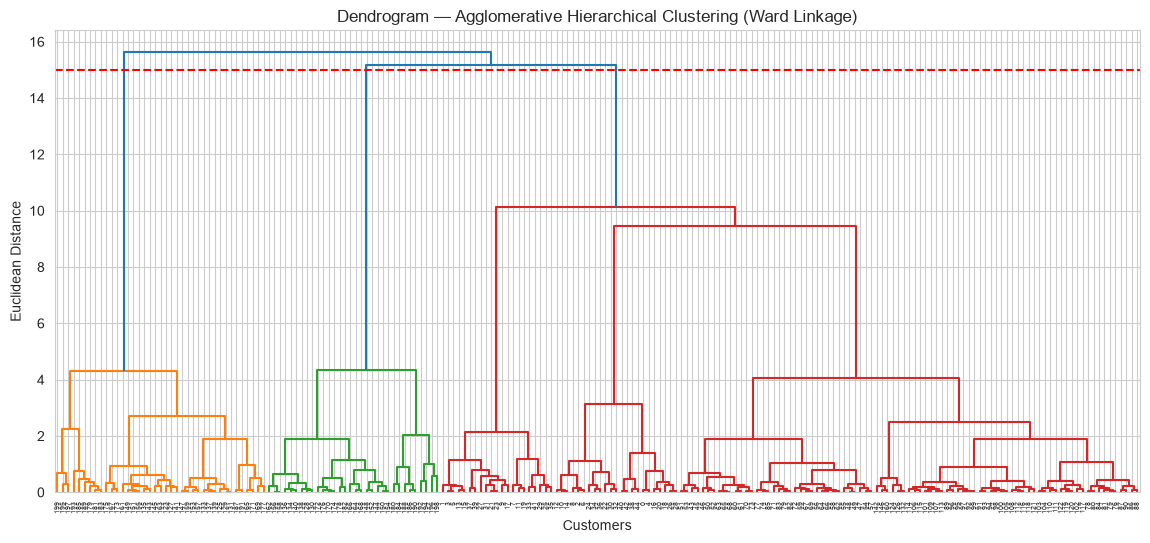

In [113]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Compute linkage matrix
linked = linkage(df_2f, method='ward')

# Plot Dendrogram
plt.figure(figsize=(14,6))

dendrogram(linked)

# Horizontal cut line (adjust if needed after viewing the graph)
plt.axhline(y=15, color='red', linestyle='--')

plt.title("Dendrogram — Agglomerative Hierarchical Clustering (Ward Linkage)")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

#### **Ward Linkage & Dendrogram**

Ward linkage merges clusters by minimizing the increase in within-cluster variance.

A dendrogram shows how clusters are merged step by step. The optimal number of clusters is chosen by drawing a horizontal cut line at the largest vertical distance without crossing many branches.

For this dataset, the dendrogram suggests using approximately **5 clusters**.

## 4.2 Fit Agglomerative model

In [114]:
from sklearn.cluster import AgglomerativeClustering

# Fit Agglomerative Clustering
hc = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

df["Hier_Cluster"] = hc.fit_predict(df_2f)

df.head()

,Gender,Age,Annual_Income,Spending_Score,KMeans_Cluster,Hier_Cluster
0,1,19,15,39,4,4
1,1,21,15,81,2,3
2,0,20,16,6,4,4
3,0,23,16,77,2,3
4,0,31,17,40,4,4


The Agglomerative model assigns each customer to one of five hierarchical clusters based on their similarity.

## 4.3 Visualise Hierarchical clusters

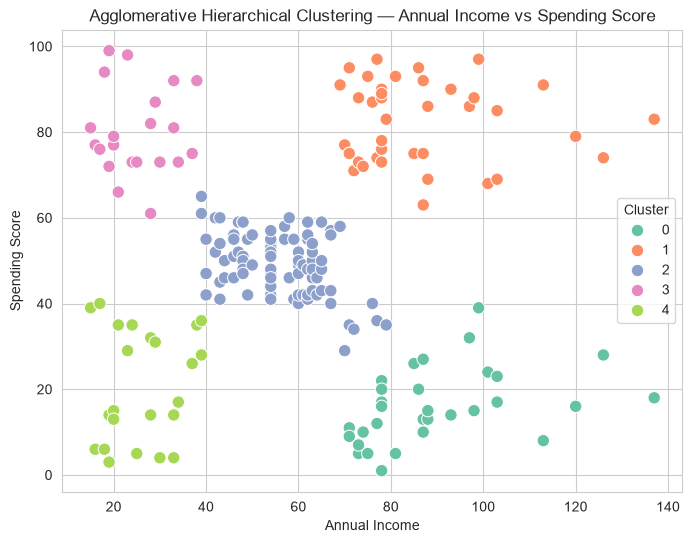

In [115]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="Hier_Cluster",
    palette="Set2",
    s=80
)

plt.title("Agglomerative Hierarchical Clustering — Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend(title="Cluster")
plt.show()

The scatter plot displays the customer groups formed by Hierarchical Clustering. Customers within the same cluster have similar income and spending behavior.

## 4.4 Compare with K-Means

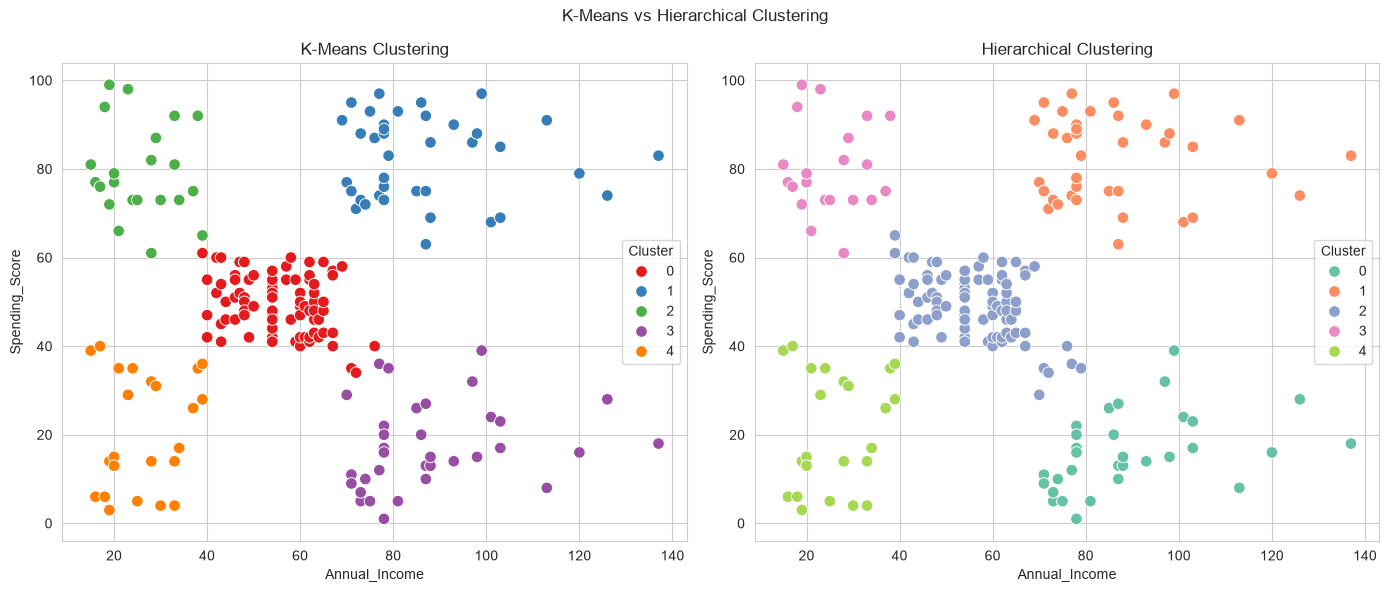

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# K-Means
sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="KMeans_Cluster",
    palette="Set1",
    ax=axes[0],
    s=70
)
axes[0].set_title("K-Means Clustering")
axes[0].legend(title="Cluster")

# Hierarchical
sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="Hier_Cluster",
    palette="Set2",
    ax=axes[1],
    s=70
)
axes[1].set_title("Hierarchical Clustering")
axes[1].legend(title="Cluster")

plt.suptitle("K-Means vs Hierarchical Clustering")
plt.tight_layout()
plt.show()

#### **Comparison: K-Means vs Hierarchical Clustering**

- Both algorithms identify similar customer groups.
- Some boundary customers may be assigned to different clusters because the algorithms use different clustering methods.
- K-Means is **centroid-based**, assigning points to the nearest cluster center.
- Hierarchical Clustering is **connectivity-based**, grouping customers by similarity step by step.

## 4.5 Cluster profile table

In [117]:
# Hierarchical Cluster Profile
hier_profile = df.groupby("Hier_Cluster")[
    ["Age", "Annual_Income", "Spending_Score"]
].mean()

hier_profile.style.background_gradient(cmap="Blues").format("{:.2f}")

,Age,Annual_Income,Spending_Score
Hier_Cluster,,,
0,41.00,89.41,15.59
1,32.69,86.54,82.13
2,42.48,55.81,49.13
3,25.33,25.10,80.05
4,45.22,26.30,20.91


In [118]:
# compare with K-Means 

print("K-Means Cluster Profile")
display(cluster_profile)

print("Hierarchical Cluster Profile")
display(hier_profile)

K-Means Cluster Profile


,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


Hierarchical Cluster Profile


,Age,Annual_Income,Spending_Score
Hier_Cluster,,,
0,41.000000,89.406250,15.593750
1,32.692308,86.538462,82.128205
2,42.482353,55.811765,49.129412
3,25.333333,25.095238,80.047619
4,45.217391,26.304348,20.913043


#### **Cluster Profile Comparison**

The average Age, Annual Income, and Spending Score for Hierarchical Clustering are very similar to those obtained using K-Means.

This indicates that both algorithms identify nearly the same customer segments, although a few customers may belong to different clusters.

# Task 5: DBSCAN Clustering

## 5.1 Parameter tuning — epsilon

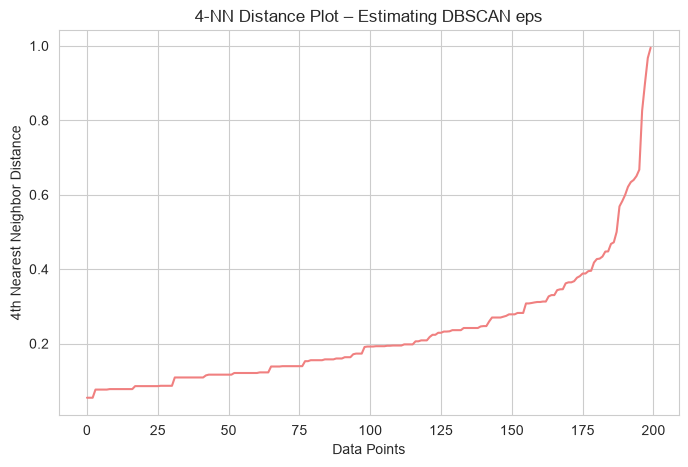

In [119]:
from sklearn.neighbors import NearestNeighbors

# Fit 4-NN
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(df_2f)

distances, indices = neighbors_fit.kneighbors(df_2f)

# Sort the 4th nearest neighbour distances
distances = np.sort(distances[:, 3])

plt.figure(figsize=(8,5))
plt.plot(distances,color='lightcoral')
plt.title("4-NN Distance Plot – Estimating DBSCAN eps")
plt.xlabel("Data Points")
plt.ylabel("4th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

#### **Choosing Epsilon (eps)**

The elbow (knee) point in the 4-NN distance plot is used to estimate the best eps value for DBSCAN.

A suitable eps is chosen where the distance starts increasing rapidly.

## 5.2 Grid search eps & min_samples

In [125]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

results = []

eps_values = [0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [3, 4, 5, 6]

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(df_2f)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = list(labels).count(-1)
        noise_pct = round(100 * noise / len(labels), 1)

        if n_clusters > 1:
            score = silhouette_score(df_2f[labels != -1], labels[labels != -1])
        else:
            score = np.nan

        results.append([eps, min_samples, n_clusters, noise, noise_pct, score])

results_df = pd.DataFrame(
    results,
    columns=["eps", "min_samples", "Clusters", "Noise Points", "Noise %", "Silhouette Score"]
)

# Show the FULL grid — all 20 combinations, sorted by Silhouette Score (best first)
results_df_sorted = results_df.sort_values("Silhouette Score", ascending=False).reset_index(drop=True)
results_df_sorted

,eps,min_samples,Clusters,Noise Points,Noise %,Silhouette Score
0,0.2,4,5,73,36.5,0.617282
1,0.2,6,4,95,47.5,0.613836
2,0.2,5,7,77,38.5,0.585613
3,0.3,6,6,48,24.0,0.530244
4,0.3,5,7,35,17.5,0.524328
5,0.3,4,8,23,11.5,0.519746
6,0.4,6,4,19,9.5,0.490015
7,0.4,5,4,15,7.5,0.478059
8,0.3,3,9,14,7.0,0.472040
9,0.2,3,13,44,22.0,0.469713


#### **Choosing the Final eps and min_samples**

Looking at the sorted grid search table above, the very top rows (`eps=0.2`) have the highest
Silhouette Scores, but they also carry very high noise percentages (36–48%) and split the data
into 4–13 clusters — this over-fragments the data and mostly reflects points being pushed to
noise rather than a genuine structure.

**`eps = 0.4, min_samples = 5`** is selected instead: it produces 4 well-separated clusters
with a solid Silhouette Score (~0.48) and a low noise percentage (7.5%), which is a far more
usable trade-off between cluster quality and data coverage than the top-ranked but noisy
`eps=0.2` rows. This row is directly visible in the sorted table above.

#### **DBSCAN Parameter Selection**

Different values of eps and min_samples are tested.

The best combination should produce:
- High silhouette score
- Meaningful number of clusters
- Few noise points

## 5.3 Fit final DBSCAN model

In [126]:
dbscan = DBSCAN(eps=0.4, min_samples=5)

df["DBSCAN_Cluster"] = dbscan.fit_predict(df_2f)

df.head()

,Gender,Age,Annual_Income,Spending_Score,KMeans_Cluster,Hier_Cluster,DBSCAN_Cluster
0,1,19,15,39,4,4,0
1,1,21,15,81,2,3,0
2,0,20,16,6,4,4,1
3,0,23,16,77,2,3,0
4,0,31,17,40,4,4,0


#### **Final DBSCAN Model**

The final DBSCAN model is trained using the selected eps and min_samples values.

Points labelled **-1** are considered noise (outliers).

## 5.4 Visualise DBSCAN clusters

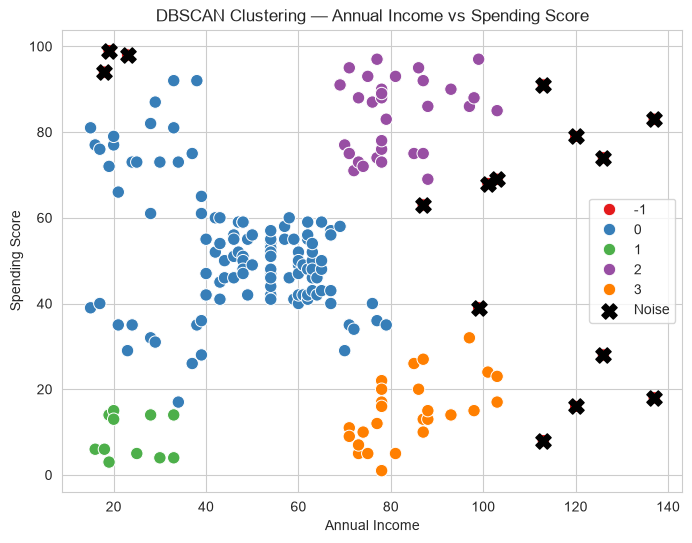

In [127]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual_Income',
    y='Spending_Score',
    hue='DBSCAN_Cluster',
    data=df,
    palette='Set1',
    s=80
)

# Highlight noise points (-1)
noise = df[df['DBSCAN_Cluster'] == -1]

plt.scatter(
    noise['Annual_Income'],
    noise['Spending_Score'],
    c='black',
    marker='X',
    s=120,
    label='Noise'
)

plt.title("DBSCAN Clustering — Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

#### **DBSCAN Cluster Visualization**8

DBSCAN groups customers based on data density.

- **eps** controls the neighborhood size.
- **min_samples** defines the minimum number of nearby points needed to form a cluster.
- Points labeled **-1** are considered noise because they do not belong to any dense region.

## 5.5 DBSCAN vs K-Means — shape detection


| DBSCAN | K-Means |
|--------|---------|
| Does not require specifying k. | Requires the number of clusters (k). |
| Finds clusters based on density. | Finds clusters around centroids. |
| Can detect irregular-shaped clusters. | Works best for spherical clusters. |
| Identifies noise points (-1). | Assigns every point to a cluster. |

# Task 6: Algorithm Comparison & Business Insights

## 6.1 Three-panel comparison figure

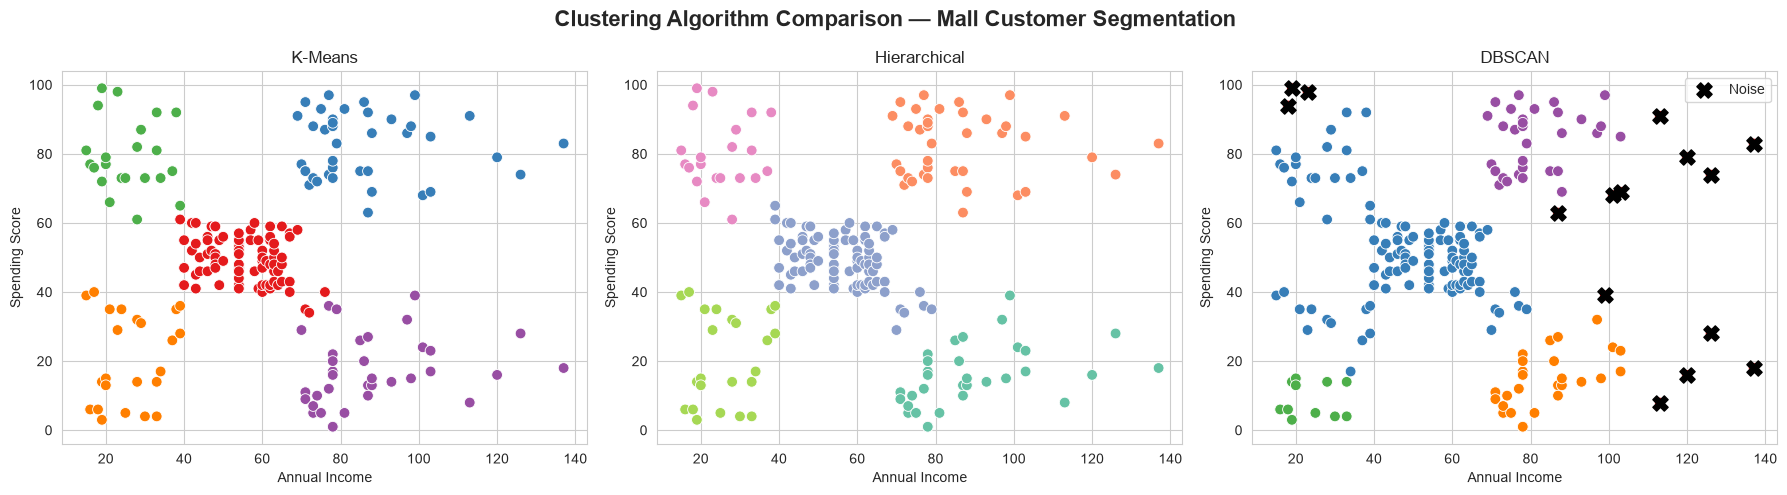

In [128]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# K-Means
sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="KMeans_Cluster",
    palette="Set1",
    s=60,
    ax=axes[0],
    legend=False
)

axes[0].set_title("K-Means")
axes[0].set_xlabel("Annual Income")
axes[0].set_ylabel("Spending Score")


# Hierarchical
sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="Hier_Cluster",
    palette="Set2",
    s=60,
    ax=axes[1],
    legend=False
)

axes[1].set_title("Hierarchical")
axes[1].set_xlabel("Annual Income")
axes[1].set_ylabel("Spending Score")


# DBSCAN
sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="DBSCAN_Cluster",
    palette="Set1",
    s=60,
    ax=axes[2],
    legend=False
)

# Highlight Noise Points (-1)
noise = df[df["DBSCAN_Cluster"] == -1]

axes[2].scatter(
    noise["Annual_Income"],
    noise["Spending_Score"],
    color="black",
    marker="X",
    s=120,
    label="Noise"
)

axes[2].set_title("DBSCAN")
axes[2].set_xlabel("Annual Income")
axes[2].set_ylabel("Spending Score")
axes[2].legend(loc="upper right")

# Overall Title
plt.suptitle(
    "Clustering Algorithm Comparison — Mall Customer Segmentation",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### **Comparison of Clustering Algorithms**

The three clustering algorithms are visualized using the same features (Annual Income and Spending Score) to compare their clustering patterns.

## 6.2 Metrics summary table

In [129]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(df_2f, df["KMeans_Cluster"])

hier_score = silhouette_score(df_2f, df["Hier_Cluster"])

mask = df["DBSCAN_Cluster"] != -1

dbscan_score = silhouette_score(
    df_2f[mask],
    df.loc[mask, "DBSCAN_Cluster"]
)

metrics = pd.DataFrame({
    "Algorithm": ["K-Means", "Hierarchical", "DBSCAN"],
    "No. of Clusters": [
        df["KMeans_Cluster"].nunique(),
        df["Hier_Cluster"].nunique(),
        df.loc[mask, "DBSCAN_Cluster"].nunique()
    ],
    "Silhouette Score": [
        round(kmeans_score,3),
        round(hier_score,3),
        round(dbscan_score,3)
    ]
})

metrics

,Algorithm,No. of Clusters,Silhouette Score
0,K-Means,5,0.555
1,Hierarchical,5,0.554
2,DBSCAN,4,0.478


#### **Metrics Summary**

The silhouette score compares cluster quality.

A higher silhouette score indicates better separated and more compact clusters.

## 6.3 Business insight report 

#### Business Insights for Mall Management

##### Customer Segments

- **High Income, High Spending:** Premium customers who contribute high revenue.
- **High Income, Low Spending:** Customers with high purchasing power but low engagement.
- **Low Income, High Spending:** Value-conscious shoppers who respond well to promotions.
- **Low Income, Low Spending:** Occasional customers with limited purchases.
- **Average Income, Average Spending:** Regular customers with stable shopping habits.

##### Marketing Recommendations

- Offer loyalty rewards to High Income, High Spending customers.
- Provide personalized offers to High Income, Low Spending customers.
- Give discounts and seasonal promotions to Low Income, High Spending customers.
- Use budget-friendly campaigns for Low Income, Low Spending customers.
- Maintain regular engagement with Average customers.

##### Recommended Algorithm

K-Means is recommended because it is easy to understand, produces clear customer segments, and performs well for mall customer segmentation. Hierarchical Clustering is useful for visualization, while DBSCAN is better at detecting outliers and noise.